# Befitting Bootstrap Analysis of imbalanced DOEs
> Ron S. Kenett, Chris Gotwalt, Laura Freeman, Peter Gedeck and Xinwei Deng


In [2]:
import common
import metrics

In [3]:
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
import pickle


# Set random seed for reproducibility
In order to reproduce the results from the publication, the random seeds must be set to 123.

In [4]:
random.seed(123)
np.random.seed(123)

# Prepare dataset

In [ ]:
# s, v0, k, t0 are mapped to x1, x2, x3, x4
n_replicate = 5
n_bootstrap = 1000
approach = 'single' # 
approach = 'individual'

full_data = common.preparePistonDataset(include_t0=False, n_replicate=n_replicate)
cases = common.prepareCases(3000, full_data['group'].max(), n_replicate=n_replicate)


In [6]:
def reduce_data(full_data, case):
    return pd.concat([group.sample(n=int(nc)) for (_, group), nc in zip(full_data.groupby('group'), case)])

reduce_data(full_data, cases[0])

,milliseconds,group,x1,x2,x3
1,58.337529,1,-1.000000,-1.000000,-1.000000
2,37.573244,2,1.000000,-1.000000,-1.000000
4,91.348734,3,-1.000000,1.000000,-1.000000
7,60.424883,4,1.000000,1.000000,-1.000000
8,70.489900,5,-1.000000,-1.000000,1.000000
10,45.096073,6,1.000000,-1.000000,1.000000
13,96.711397,7,-1.000000,1.000000,1.000000
14,57.138131,8,1.000000,1.000000,1.000000
16,60.172220,9,0.000000,0.000000,0.000000
18,68.776173,10,0.000000,0.000000,0.000000


<Axes: >

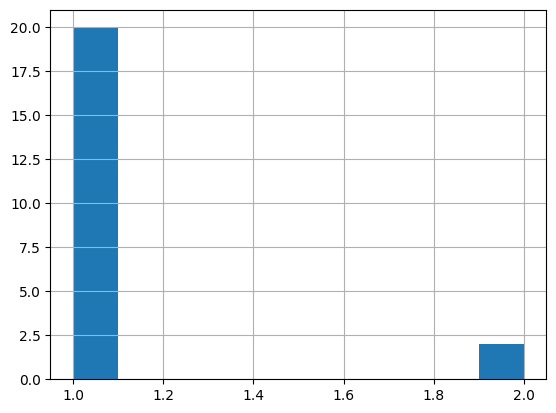

In [7]:
data = reduce_data(full_data, cases[0])
data['group'].value_counts().hist()

# Build a variety of models using main effects and interactions

In [8]:
main_terms_significant = 'x1 + x2 + x3'
interaction_terms = 'x1:x2 + x1:x3 + x2:x3'
quadratic_terms = 'I(x1**2) + I(x2**2) + I(x3**2)'
formula_full = f'milliseconds ~ {main_terms_significant} + {interaction_terms} + {quadratic_terms}'
group = ['x1', 'x2', 'x3']

# Bootstrap analysis

In [8]:
methods = {
    'BA': (common.bootstrapAnalysis, {}),
    'BBA': (common.befittingBootstrapAnalysis, {'group': group}),
    'wBA': (common.wildBootstrapAnalysis, {}),
}

def compareMethods(data, nrepeats):
    results = {}
    for key, (method, additional_kwargs) in methods.items():
        kwargs = {'nrepeats': nrepeats, **additional_kwargs}
        results.update({
            f'{key}_full': method(data, formula_full, **kwargs),
        })
    return results

std_results = []
coef_results = []
for seed, case in enumerate(tqdm.tqdm(cases)):
    L1_metric = metrics.L1_distance(case)
    if approach == 'individual':
        full_data = common.preparePistonDataset(include_t0=False, n_replicate=n_replicate, seed=seed)
    data = reduce_data(full_data, case)
    for key, result in compareMethods(data, n_bootstrap).items():
        r = result.std()
        r['metric'] = L1_metric
        r['method'] = key
        std_results.append(r)
        r = result.mean()
        r['metric'] = L1_metric
        r['method'] = key
        coef_results.append(r)
std_results = pd.DataFrame(std_results)
coef_results = pd.DataFrame(coef_results)
    

  2%|▏         | 69/3000 [11:26<8:06:16,  9.95s/it]


KeyboardInterrupt: 

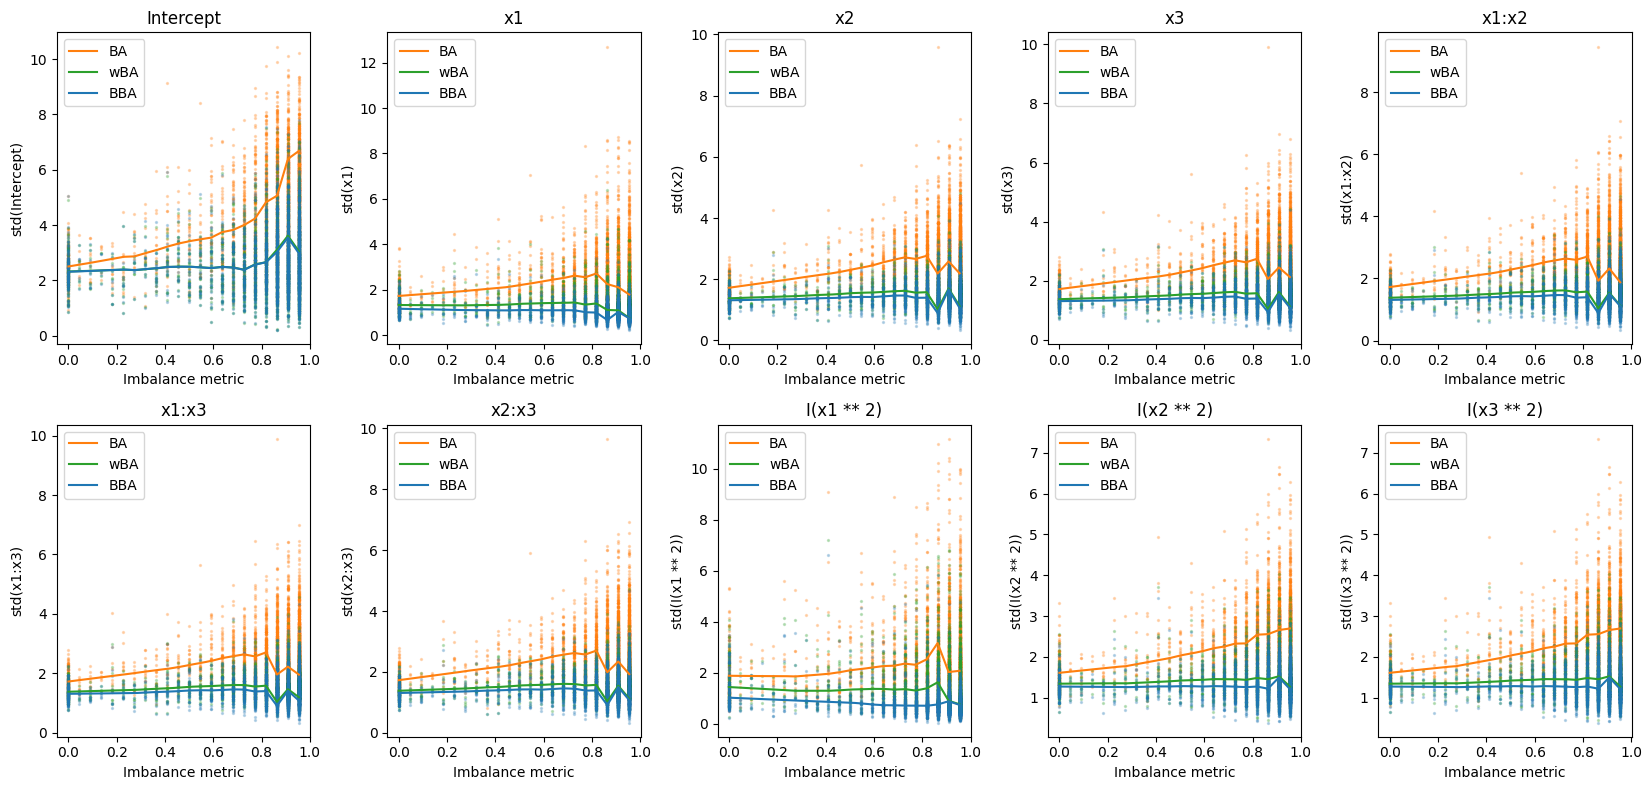

In [ ]:
def plot_results(results, term, method, color, ax, size, alpha):
    subset = results[results['method'] == method]
    subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
    common.make_lowess(subset['metric'], subset[term]).plot(x='x', y='y', ax=ax, color=color, label=method.replace('_full', ''))


results = std_results

terms = ['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']
ncols=5; nrows=2
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[20 * ncols / 6, 4 * nrows])
axes = itertools.chain(*axes)
size=2; alpha=0.25
for ax, term in zip(axes, terms):
    plot_results(std_results, term, 'BA_full', 'C1', ax, size, alpha)
    plot_results(std_results, term, 'wBA_full', 'C2', ax, size, alpha)
    plot_results(std_results, term, 'BBA_full', 'C0', ax, size, alpha)
    ax.set_title(term)
    ax.set_ylabel(f'std({term})')
    ax.set_xlabel('Imbalance metric')
plt.tight_layout()

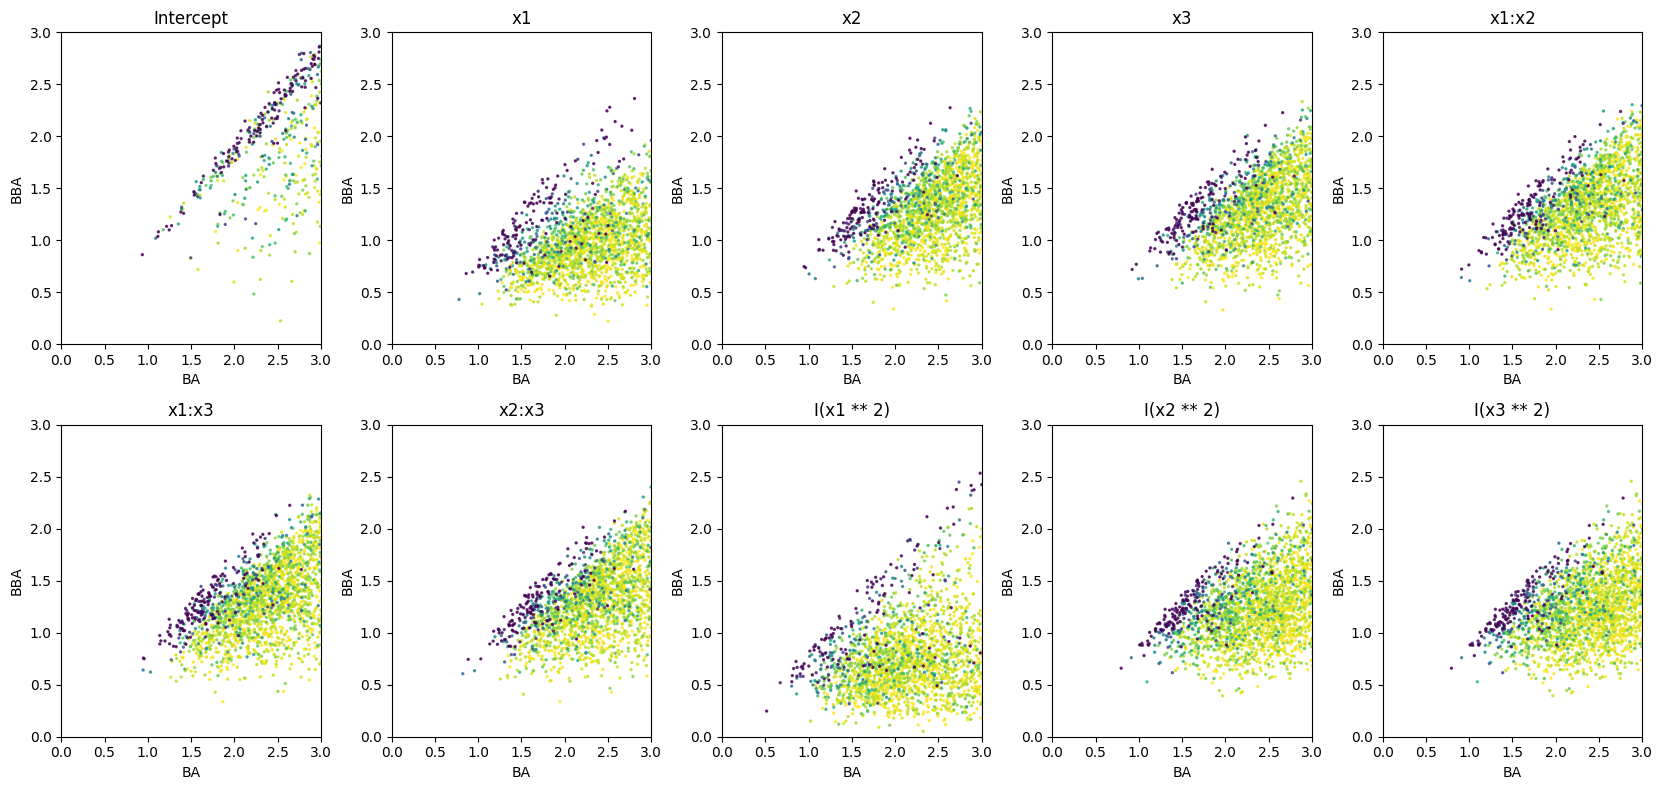

In [ ]:
ncols=5; nrows=2
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[20 * ncols / 6, 4 * nrows])
axes = itertools.chain(*axes)
for ax, term in zip(axes, terms):
    x = results[results['method'] == 'BA_full'][term]
    metric = results[results['method'] == 'BA_full']['metric']
    y = results[results['method'] == 'BBA_full'][term]
    ax.scatter(x, y, c=metric, alpha=0.75,s=2)
    ax.set_xlabel('BA')
    ax.set_ylabel('BBA')
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_title(term)
plt.tight_layout()

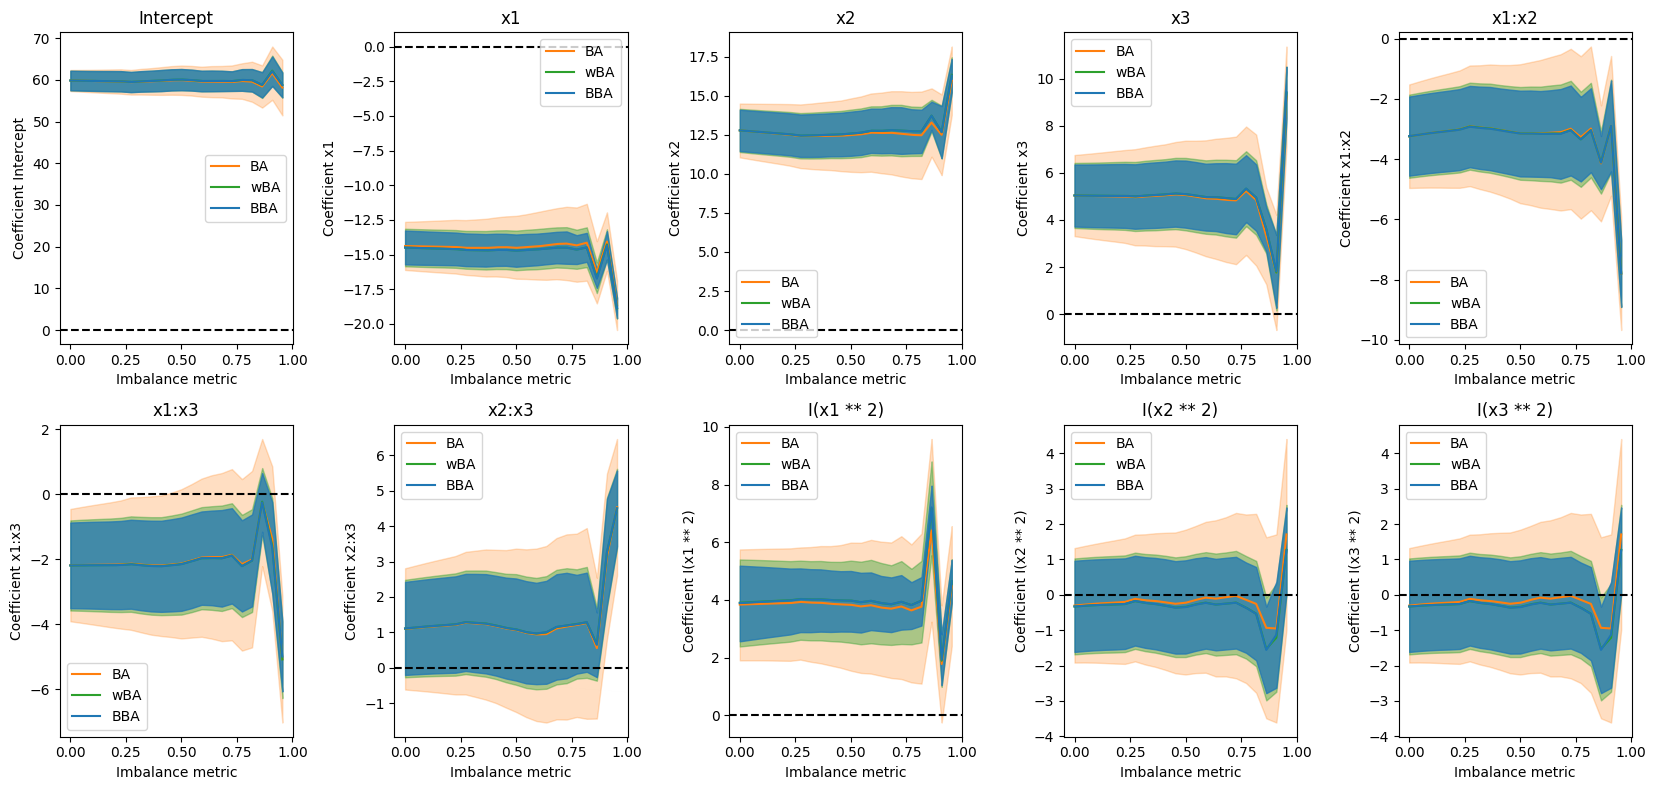

In [ ]:
def plot_results(coef_results, std_results, term, method, color, ax, size, alpha):
    coef_subset = coef_results[coef_results['method'] == method]
    std_subset = std_results[std_results['method'] == method]
    coeff_lowess = common.make_lowess(coef_subset['metric'], coef_subset[term])
    coeff_upper_lowess = common.make_lowess(coef_subset['metric'], coef_subset[term] + std_subset[term])
    coeff_lower_lowess = common.make_lowess(coef_subset['metric'], coef_subset[term] - std_subset[term])
    ax.fill_between(coeff_lowess['x'], coeff_lower_lowess['y'], coeff_upper_lowess['y'], color=color, alpha=alpha)
    coeff_lowess.plot(x='x', y='y', ax=ax, color=color, label=method.replace('_full', ''))
    

terms = ['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']
ncols=5; nrows=2
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[20 * ncols / 6, 4 * nrows])
axes = itertools.chain(*axes)
size=2; alpha=0.25
for ax, term in zip(axes, terms):
    plot_results(coef_results, std_results, term, 'BA_full', 'C1', ax, size, 0.25)
    plot_results(coef_results, std_results, term, 'wBA_full', 'C2', ax, size, 0.4)
    plot_results(coef_results, std_results, term, 'BBA_full', 'C0', ax, size, 0.75)
    ax.set_title(term)
    ax.set_ylabel(f'Coefficient {term}')
    ax.set_xlabel('Imbalance metric')
    ax.axhline(0, color='black', linestyle='--')
plt.tight_layout()

In [ ]:
if approach == 'individual':
    open(f'results_individual_{n_replicate}_{n_bootstrap}.pkl', 'wb').write(pickle.dumps({'std_results': std_results, 'coef_results': coef_results}))
else:
    open(f'results_{n_replicate}_{n_bootstrap}.pkl', 'wb').write(pickle.dumps({'std_results': std_results, 'coef_results': coef_results}))


- Overlay OLS results
- Repeat with max replicates 4, 3, 2